In [ ]:
import sys
sys.path.append('C:/Users/sliso/LastTradingProject_7052026/indicators')

In [8]:
import pandas as pd
import numpy as np
from numba import njit
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from SignalDecorator import signal  # your decorator
import talib as ta
from RsiDiv import RsiDiv


In [9]:
data=pd.read_csv("../df_test.csv", parse_dates=['Date'], index_col='Date')

In [10]:
df=pd.read_csv("../all_data_EUR_USD.csv", parse_dates=['Date'], index_col='Date')

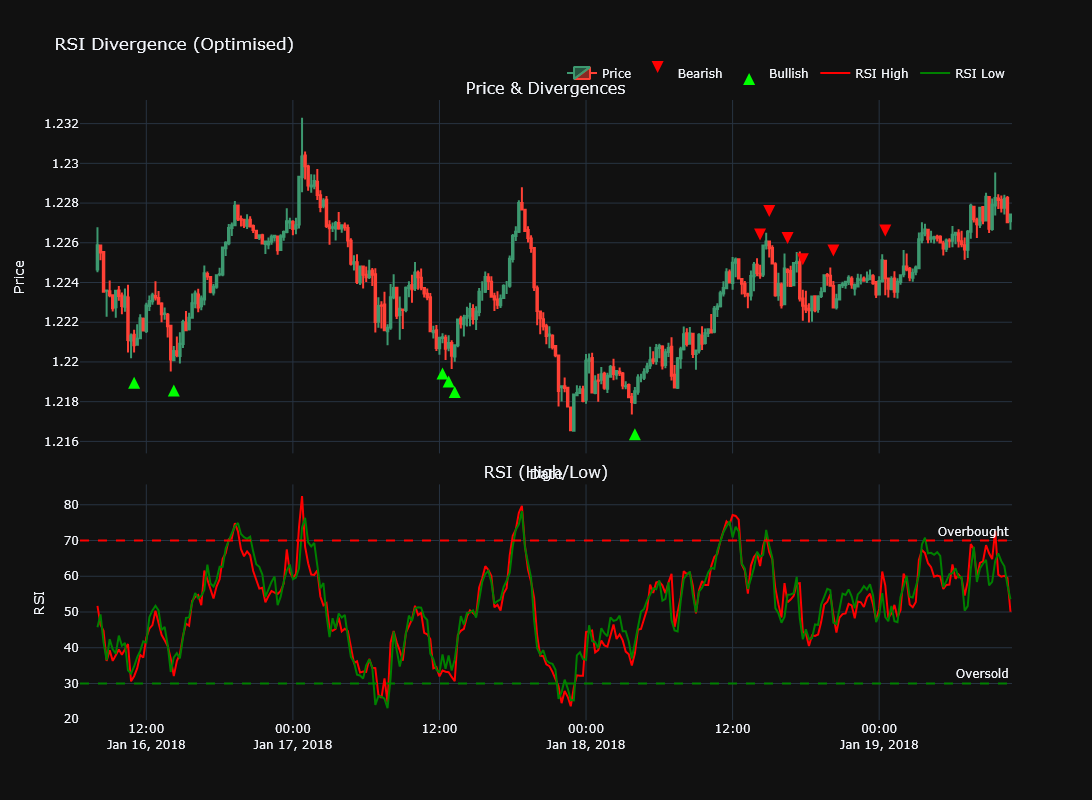

In [11]:
div = RsiDiv(data=data, lookback_bars=50, min_price_move=0.0003)

bearish = div.bearish_signal()
bullish = div.bullish_signal()
div.plot(start_idx=1000, end_idx=1300)

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from itertools import product
#from RSIDivergence import RSIDivergence   # your class

# -----------------------------
# 1. Simple backtest function
# -----------------------------
def backtest_signals(df, bearish, bullish, exit_bars=5,
                     spread_pips=1, point=0.0001):
    """
    Enters on signal, exits after exit_bars (or at end of data).
    Returns Profit Factor.
    """
    # Convert pips to price units
    cost = spread_pips * point
    trades = []  # (direction, entry_price, exit_price, exit_bar)
    
    for direction, sig in [('short', bearish), ('long', bullish)]:
        idx = np.where(sig)[0]
        for i in idx:
            if i + exit_bars >= len(df):
                continue
            entry_price = df['Close'].iloc[i]   # entry on close of signal bar
            exit_price = df['Close'].iloc[i + exit_bars]
            if direction == 'long':
                pnl = exit_price - entry_price - cost
            else:
                pnl = entry_price - exit_price - cost
            trades.append(pnl)
    
    if not trades:
        return 0.0
    trades = np.array(trades)
    wins = trades[trades > 0].sum()
    losses = abs(trades[trades < 0].sum())
    if losses == 0:
        return np.inf
    return wins / losses

# -----------------------------
# 2. Grid search
# -----------------------------
# Sample ranges (EURUSD 15min)
min_price_moves = [0, 0.0002, 0.0003, 0.0005, 0.0007, 0.0010]
min_rsi_moves   = [0, 1, 2, 3, 5, 7, 10]

# Split: 2006-2018 in-sample, 2019-2023 out-of-sample
split_date = '2019-01-01'
df_in  = df.loc[:split_date].copy()
df_out = df.loc[split_date:].copy()

# Fixed baseline parameters (tune these separately if needed)
base_params = dict(
    rsi_period=14,
    price_left_window=3,
    price_confirm_bars=1,
    rsi_left_window=3,
    rsi_confirm_bars=1,
    lookback_bars=100,
    overbought=70.0,
    oversold=30.0
)

param_combinations = list(product(enumerate(min_price_moves), enumerate(min_rsi_moves)))

results_in  = np.zeros((len(min_price_moves), len(min_rsi_moves)))
results_out = np.zeros((len(min_price_moves), len(min_rsi_moves)))

# tqdm progress bar over all combinations
for (i, min_p), (j, min_r) in tqdm(param_combinations, desc="Optimising"):
    # In-sample
    ind = RSIDivergence(df_in, **base_params, min_price_move=min_p, min_rsi_move=min_r)
    bearish = ind._bearish
    bullish = ind._bullish
    pf = backtest_signals(df_in, bearish, bullish, exit_bars=12)
    results_in[i, j] = pf
    
    # Out-of-sample
    ind_out = RSIDivergence(df_out, **base_params, min_price_move=min_p, min_rsi_move=min_r)
    pf_out = backtest_signals(df_out, ind_out._bearish, ind_out._bullish, exit_bars=12)
    results_out[i, j] = pf_out


# -----------------------------
# 3. Find best in-sample pair
# -----------------------------
best_idx = np.unravel_index(np.nanargmax(results_in), results_in.shape)
best_p, best_r = min_price_moves[best_idx[0]], min_rsi_moves[best_idx[1]]
print(f"Best in-sample: min_price_move={best_p:.5f}, min_rsi_move={best_r}, Profit Factor={results_in[best_idx]:.2f}")
print(f"Corresponding out-of-sample Profit Factor: {results_out[best_idx]:.2f}")

# -----------------------------
# 4. Visualise (heatmaps)
# -----------------------------
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, title in zip([ax1, ax2], [results_in, results_out], ['In-sample', 'Out-of-sample']):
    im = ax.imshow(res, origin='lower', aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(min_rsi_moves)))
    ax.set_xticklabels(min_rsi_moves)
    ax.set_yticks(range(len(min_price_moves)))
    ax.set_yticklabels([f"{p:.4f}" for p in min_price_moves])
    ax.set_xlabel('min_rsi_move')
    ax.set_ylabel('min_price_move')
    ax.set_title(title)
    # Annotate best in-sample on in-sample plot
    if title == 'In-sample':
        ax.scatter(best_idx[1], best_idx[0], marker='*', s=200, c='blue', edgecolors='white')
    plt.colorbar(im, ax=ax, label='Profit Factor')

plt.tight_layout()
plt.show()